# Feature Engineering — Telco Churn

---

**Objetivo:** Transformar as variáveis brutas do dataset em **features informativas** que ampliem o sinal preditivo para o modelo de churn, sem introduzir data leakage.

**Contexto:** A análise exploratória (notebook 01) revelou que o churn é fortemente influenciado por tipo de contrato, tempo de permanência e uso de serviços adicionais. Neste notebook, criamos variáveis derivadas que capturem essas relações de forma mais direta e quantificável para os algoritmos de ML.

**Estrutura:**
1. **Setup e Carregamento** — Importação de dependências e dados brutos
2. **Tratamentos Iniciais** — Correção de tipos e conversão do target
3. **Feature Engineering** — Criação de novas features em 5 categorias (tenure, cobrança, contrato, interações, transformações matemáticas)
4. **Seleção de Features (IV)** — Ranking de poder preditivo para priorizar features
5. **Pipeline de Preprocessamento** — Construção do pipeline de transformação (scaler + encoder)
6. **Validação e Export** — Verificação de leakage, salvamento de artefatos

---

## 1. Setup e Carregamento

Importação das bibliotecas, configuração dos paths e carregamento do dataset bruto. As configurações do projeto (colunas, faixas de tenure, etc.) são centralizadas em `src/config.py` para garantir consistência entre notebooks e scripts de produção.

In [6]:
import sys
import json
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Path do projeto
PROJ_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJ_ROOT))

# Imports do projeto
from src.config import (
 DATA_DIR_RAW, DATA_DIR_PROCESSED, FILENAME,
 TARGET, ID_COL, RANDOM_STATE,
 TENURE_BINS, TENURE_LABELS
)
from src.preprocessing import build_preprocessor
from src.notebook_utils import (
 calculate_iv_categorical,
 calculate_iv_numeric,
 plot_iv_ranking_and_summary
)

# Configurações
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

In [7]:
# Carregar dados
df = pd.read_csv(DATA_DIR_RAW / FILENAME)
print(f"Dataset: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

Dataset: 7,043 linhas × 21 colunas


## 2. Tratamentos Iniciais

Antes de criar novas features, aplicamos os tratamentos identificados na EDA:
- **Target:** Conversão de `'Yes'/'No'` para `1/0` (formato binário para classificação)
- **TotalCharges:** Correção de tipo (`object` → `float`) e preenchimento de valores ausentes com zero para clientes novos (`tenure=0`)
- **Linhas inválidas:** Remoção de eventuais registros com target nulo

In [8]:
# 2.1 Target: converter para binário
if df[TARGET].dtype == 'object':
   df[TARGET] = df[TARGET].map({'Yes': 1, 'No': 0})

# 2.2 TotalCharges: converter para numérico e tratar novos clientes
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.loc[(df['tenure'] == 0) & (df['TotalCharges'].isna()), 'TotalCharges'] = 0

# 2.3 Remover linhas com target nulo
df = df.dropna(subset=[TARGET]).reset_index(drop=True)

print(f"\nDistribuição do Target:")
print(df[TARGET].value_counts(normalize=True).rename({0: 'No Churn', 1: 'Churn'}).apply(lambda x: f"{x:.1%}"))


Distribuição do Target:
Churn
No Churn    73.5%
Churn       26.5%
Name: proportion, dtype: object


## 3. Feature Engineering

Criação de novas variáveis baseadas nos padrões identificados na análise exploratória. Cada feature é motivada por um insight de negócio ou estatístico e organizada em categorias temáticas.

**Princípio fundamental:** Toda feature deve capturar informação *já disponível no momento da predição* — nunca utilizar dados futuros ou derivados do target para evitar **data leakage**.

### 3.1 Features de Tenure (Tempo de Cliente)

A EDA mostrou que clientes com tenure baixo (< 12 meses) têm ~50% de churn, enquanto clientes com tenure alto (> 48 meses) ficam abaixo de 10%. Capturamos esse padrão com duas features:

| Feature | Descrição | Motivação |
|---------|-----------|----------|
| `new_customer_flag` | Indicador binário de cliente novo (`tenure=0`) | Clientes recém-chegados têm comportamento e risco distintos dos demais |
| `tenure_group` | Faixas de permanência (categorias ordinais) | Transforma relação não-linear tenure→churn em segmentos interpretáveis |

In [9]:
# Cliente novo
df['new_customer_flag'] = (df['tenure'] == 0).astype(int)

# Grupos de tenure
df['tenure_group'] = pd.cut(
    df['tenure'], 
    bins=TENURE_BINS, 
    labels=TENURE_LABELS, 
    include_lowest=True
)

print("tenure_group:")
print(df['tenure_group'].value_counts().sort_index())

tenure_group:
tenure_group
0-6m     1481
7-12m     705
1-2a     1024
2-4a     1594
4-6a     2239
Name: count, dtype: int64


### 3.2 Features de Cobrança

Variáveis que capturam padrões de gasto e anomalias de cobrança. A hipótese é que **clientes com percepção de custo elevado** (especialmente sem contrapartida de serviços adicionais) são mais propensos ao churn.

| Feature | Descrição | Motivação |
|---------|-----------|----------|
| `avg_monthly_charge` | `TotalCharges / tenure` (média mensal real) | Normaliza o acumulado pelo tempo, revelando o custo efetivo mensal |
| `charges_mismatch_flag` | Divergência > 30% entre real e esperado | Detecta ajustes de plano, promoções expiradas ou cobranças irregulares |
| `is_high_MonthlyCharges` | Acima da mediana de gasto | Flag simples para segmentar heavy spenders |
| `MonthlyCharges_binned` | Quartis de cobrança mensal | Captura efeitos não-lineares do preço sobre o churn |

In [10]:
# Média mensal (evita divisão por zero)
df['avg_monthly_charge'] = np.where(
    df['tenure'] > 0, 
    df['TotalCharges'] / df['tenure'],0
)

# Flag de divergência de cobrança
expected = df['MonthlyCharges'] * df['tenure']
df['charges_mismatch_flag'] = (
 abs(df['TotalCharges'] - expected) / (df['TotalCharges'] + 1e-6) > 0.3
).astype(int)

# Heavy spender
df['is_high_MonthlyCharges'] = (
 df['avg_monthly_charge'] > df['avg_monthly_charge'].median()
).astype(int)

# Binning de MonthlyCharges
quantiles = df['MonthlyCharges'].quantile([0, 0.25, 0.5, 0.75, 1]).values
bin_edges = np.unique(quantiles)
if len(bin_edges) < 5:
 bin_edges = np.linspace(df['MonthlyCharges'].min(), df['MonthlyCharges'].max(), 5)
labels = ['muito_baixo', 'baixo', 'medio', 'alto'][:len(bin_edges)-1]
df['MonthlyCharges_binned'] = pd.cut(
 df['MonthlyCharges'], bins=bin_edges, labels=labels, include_lowest=True
)

### 3.3 Features de Contrato

O tipo de contrato foi identificado na EDA como a variável com **maior IV** e a diferença de churn mais acentuada: 43% em contratos mensais vs ~3% em contratos de 2 anos. Criamos representações complementares para explorar esse sinal:

| Feature | Descrição | Motivação |
|---------|-----------|----------|
| `is_monthly_contract` | Indicador de contrato mensal | 43% de churn — o tipo de contrato com maior risco |
| `long_term_contract` | Indicador de contrato ≥ 1 ano | Fator protetivo — compromisso reduz churn substancialmente |
| `contract_risk_ordinal` | Codificação ordinal (0-2) por risco | Preserva a ordem natural de risco entre os tipos de contrato |

In [11]:
# Flags de contrato
df['is_monthly_contract'] = (df['Contract'] == 'Month-to-month').astype(int)
df['long_term_contract'] = df['Contract'].isin(['One year', 'Two year']).astype(int)

# Codificação ordinal baseada no churn rate histórico
contract_order = df.groupby('Contract')[TARGET].mean().sort_values(ascending=False).index
contract_map = {name: i for i, name in enumerate(contract_order)}
df['contract_risk_ordinal'] = df['Contract'].map(contract_map)

print("Churn rate por contrato:")
print(df.groupby('Contract')[TARGET].mean().sort_values(ascending=False).apply(lambda x: f"{x:.1%}"))

Churn rate por contrato:
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn, dtype: object


### 3.4 Interações Comportamentais

Features que combinam duas ou mais variáveis para capturar **padrões de risco compostos** que variáveis isoladas não expressam. A ideia é modelar o perfil de cliente de alto risco como uma conjunção de fatores:

| Feature | Descrição | Motivação |
|---------|-----------|----------|
| `early_churn_risk` | Contrato mensal E tenure < 12 meses | O perfil de maior risco combinado — sem vínculo e recém-chegado |
| `price_sensitive_contract` | Contrato mensal E gasto acima da mediana | Clientes vulneráveis à concorrência — pagam caro sem compromisso |
| `tenure_vs_contract_avg` | `tenure / média_tenure_do_grupo_contrato` | Detecta retenção anômala — cliente muito abaixo da média do seu grupo pode estar prestes a sair |

In [12]:
# Risco de churn precoce
df['early_churn_risk'] = (
 (df['is_monthly_contract'] == 1) & (df['tenure'] < 12)
).astype(int)

# Sensibilidade a preço
df['price_sensitive_contract'] = (
 (df['is_monthly_contract'] == 1) & 
 (df['MonthlyCharges'] > df['MonthlyCharges'].median())
).astype(int)

# Tenure relativo ao grupo de contrato
contract_avg = df.groupby('Contract')['tenure'].transform('mean')
df['tenure_vs_contract_avg'] = df['tenure'] / contract_avg

print(f"\nearly_churn_risk: {df['early_churn_risk'].sum():,} clientes ({df['early_churn_risk'].mean():.1%})")
print(f"\nprice_sensitive_contract: {df['price_sensitive_contract'].sum():,} clientes ({df['price_sensitive_contract'].mean():.1%})")
print(f"\ntenure_vs_contract_avg: {df['tenure_vs_contract_avg'].mean():.2f}")


early_churn_risk: 1,908 clientes (27.1%)

price_sensitive_contract: 2,043 clientes (29.0%)

tenure_vs_contract_avg: 1.00


### Validação dos Insights: Features Criadas vs Churn

Antes de avançar para as transformações matemáticas, verificamos se as features criadas realmente capturam padrões que diferenciam churners de não-churners. Calculamos a taxa de churn quando cada flag está ativada e comparamos com a taxa base (~26.5%).

In [13]:
base_churn = df[TARGET].mean()

print("Principais insights iniciais:")
print(f"• Churn geral: {base_churn:.1%}")

# 1) Contrato (sinal mais forte já observado)
contract_churn = df.groupby('Contract')[TARGET].mean().sort_values(ascending=False)
print("\n• Churn por tipo de contrato:")
for k, v in contract_churn.items():
    print(f"  - {k}: {v:.1%}")

# 2) Tenure (clientes mais novos tendem a maior risco)
tenure_churn = (
    df.groupby('tenure_group', observed=False)[TARGET]
      .mean()
      .sort_values(ascending=False)
)
top_tenure = tenure_churn.index[0]
print(f"\n• Faixa de tenure com maior churn: {top_tenure} ({tenure_churn.iloc[0]:.1%})")

# 3) Features comportamentais criadas
flag_features = [
    'is_monthly_contract',
    'early_churn_risk',
    'price_sensitive_contract',
    'long_term_contract',
    'new_customer_flag',
    'charges_mismatch_flag'
]

rows = []
for col in flag_features:
    if col in df.columns:
        subset = df[df[col] == 1]
        churn_flag = subset[TARGET].mean() if len(subset) else np.nan
        rows.append({
            'feature': col,
            'prevalencia': subset.shape[0] / len(df),
            'churn_quando_1': churn_flag,
            'delta_vs_base_pp': (churn_flag - base_churn) * 100 if pd.notna(churn_flag) else np.nan
        })

insights_flags = pd.DataFrame(rows).sort_values('delta_vs_base_pp', ascending=False)

print("\n• Impacto das flags (ordenado por ganho de risco vs base):")
display(insights_flags.style.format({
    'prevalencia': '{:.1%}',
    'churn_quando_1': '{:.1%}',
    'delta_vs_base_pp': '{:+.1f} pp'
}))

# 4) Faixas de cobrança
charges_churn = (
    df.groupby('MonthlyCharges_binned', observed=False)[TARGET]
      .mean()
      .sort_values(ascending=False)
)
print("\n• Churn por faixa de MonthlyCharges_binned:")
for k, v in charges_churn.items():
    print(f"  - {k}: {v:.1%}")

#  5) Tenure relativo ao grupo de contrato 

tenure_churn = df.groupby('tenure_vs_contract_avg', observed=False)[TARGET].mean().sort_values(ascending=False)
print(f"\n• Tenure relativo ao grupo de contrato (média): {df['tenure_vs_contract_avg'].mean():.2f}")

# 6) Sensibilidade a preço
price_sensitivity_churn = df.groupby('price_sensitive_contract', observed=False)[TARGET].mean().sort_values(ascending=False)
print("\n• Churn por sensibilidade a preço:")
for k, v in price_sensitivity_churn.items():
    print(f"  - price_sensitive_contract={k}: {v:.1%}")


# 7) Risco de churn precoce
early_churn_risk_churn = df.groupby('early_churn_risk', observed=False)[TARGET].mean().sort_values(ascending=False)
print("\n• Churn por risco de churn precoce:")
for k, v in early_churn_risk_churn.items():
    print(f"  - early_churn_risk={k}: {v:.1%}")


Principais insights iniciais:
• Churn geral: 26.5%

• Churn por tipo de contrato:
  - Month-to-month: 42.7%
  - One year: 11.3%
  - Two year: 2.8%

• Faixa de tenure com maior churn: 0-6m (52.9%)

• Impacto das flags (ordenado por ganho de risco vs base):


,feature,prevalencia,churn_quando_1,delta_vs_base_pp
2,price_sensitive_contract,29.0%,52.8%,+26.3 pp
1,early_churn_risk,27.1%,51.9%,+25.4 pp
0,is_monthly_contract,55.0%,42.7%,+16.2 pp
5,charges_mismatch_flag,0.2%,25.0%,-1.5 pp
3,long_term_contract,45.0%,6.8%,-19.8 pp
4,new_customer_flag,0.2%,0.0%,-26.5 pp



• Churn por faixa de MonthlyCharges_binned:
  - medio: 37.5%
  - alto: 32.9%
  - baixo: 24.6%
  - muito_baixo: 11.2%

• Tenure relativo ao grupo de contrato (média): 1.00

• Churn por sensibilidade a preço:
  - price_sensitive_contract=1: 52.8%
  - price_sensitive_contract=0: 15.8%

• Churn por risco de churn precoce:
  - early_churn_risk=1: 51.9%
  - early_churn_risk=0: 17.1%


### Conclusão Parcial dos Insights de Churn

Os resultados confirmam que o churn é predominantemente explicado pela combinação de **contrato mensal + baixa permanência + maior sensibilidade a preço**. As features criadas capturam bem esses padrões, com deltas significativos em relação à taxa base:
- `early_churn_risk` e `is_monthly_contract` apresentam os maiores ganhos de risco (> +15 p.p. acima da base)
- `long_term_contract` funciona como fator protetivo (churn muito abaixo da base)

Esses resultados justificam avançar para as **transformações matemáticas** e **seleção por IV**.

### 3.5 Transformações Matemáticas

Aplicamos transformações não-lineares às variáveis de cobrança para melhorar a performance de modelos que assumem relações lineares (ex: Logistic Regression):

- **Log** (`np.log1p`) — Reduz a assimetria (skewness) de distribuições com cauda longa como `TotalCharges`, aproximando-a de uma normal. Melhora convergência de modelos lineares e regularizados.
- **Squared** (`x²`) — Captura efeitos quadráticos, permitindo que modelos lineares modelem curvas de U ou J sem necessidade de kernels.

In [14]:
# Transformações para variáveis de cobrança
charge_cols = ['MonthlyCharges', 'TotalCharges', 'avg_monthly_charge']

for col in charge_cols:
 df[f'{col}_log'] = np.log1p(df[col].clip(lower=0))
 df[f'{col}_squared'] = df[col] ** 2

### Resumo das Features Criadas

Listagem completa de todas as features derivadas, comparadas com as colunas originais do dataset. Cada feature foi motivada por um insight da EDA e projetada para ser calculável no momento da inferência (sem data leakage).

In [15]:
# Identificar features criadas
original_cols = ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
 'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

new_features = [c for c in df.columns if c not in original_cols]
print(f" {len(new_features)} novas features criadas:")
for f in sorted(new_features):
 print(f" - {f}")

 18 novas features criadas:
 - MonthlyCharges_binned
 - MonthlyCharges_log
 - MonthlyCharges_squared
 - TotalCharges_log
 - TotalCharges_squared
 - avg_monthly_charge
 - avg_monthly_charge_log
 - avg_monthly_charge_squared
 - charges_mismatch_flag
 - contract_risk_ordinal
 - early_churn_risk
 - is_high_MonthlyCharges
 - is_monthly_contract
 - long_term_contract
 - new_customer_flag
 - price_sensitive_contract
 - tenure_group
 - tenure_vs_contract_avg


## 4. Seleção de Features (Information Value)

Utilizamos o **Information Value (IV)** para criar um ranking objetivo de poder preditivo de cada feature — incluindo as recém-criadas. Isso permite validar se as features derivadas realmente agregam valor em relação às originais e identificar quais devem ser priorizadas no modelo.

**Escala de referência:**
| Faixa de IV | Classificação | Ação |
|-------------|---------------|------|
| < 0.02 | Sem poder preditivo | Descartar ou investigar |
| 0.02 – 0.10 | Fraco | Manter se fizer sentido de negócio |
| 0.10 – 0.30 | Médio | Incluir no modelo |
| > 0.30 | Forte | Feature prioritária |

In [16]:
# Identificar colunas por tipo
NUMERIC_COLS = [c for c in df.select_dtypes(include=['number']).columns 
 if c not in [TARGET, ID_COL] and c in df.columns]
CATEGORICAL_COLS = [c for c in df.select_dtypes(include=['object', 'category']).columns 
 if c not in [TARGET, ID_COL] and c in df.columns]

print(f"Numéricas: {len(NUMERIC_COLS)} | Categóricas: {len(CATEGORICAL_COLS)}")

Numéricas: 20 | Categóricas: 17


In [17]:
# Calcular IV para todas as features
iv_rows = []

for col in CATEGORICAL_COLS:
    try:
        iv = calculate_iv_categorical(df, col, TARGET)
        iv_rows.append({'Feature': col, 'Type': 'categorical', 'IV': float(iv)})
    except Exception as e:
        print(f"[WARN] {col}: {e}")

for col in NUMERIC_COLS:
    try:
        iv = calculate_iv_numeric(df, col, TARGET)
        iv_rows.append({'Feature': col, 'Type': 'numeric', 'IV': float(iv)})
    except Exception as e:
        print(f"[WARN] {col}: {e}")

iv_df = pd.DataFrame(iv_rows).sort_values('IV', ascending=False).reset_index(drop=True)

print("\nTOP 15 Features por IV:")
iv_df.head(15)


TOP 15 Features por IV:


,Feature,Type,IV
0,Contract,categorical,1.234133
1,contract_risk_ordinal,numeric,0.837648
2,tenure,numeric,0.828516
3,OnlineSecurity,categorical,0.716063
4,tenure_group,categorical,0.712181
5,TechSupport,categorical,0.697891
6,InternetService,categorical,0.616479
7,tenure_vs_contract_avg,numeric,0.554112
8,OnlineBackup,categorical,0.527278
9,DeviceProtection,categorical,0.498404


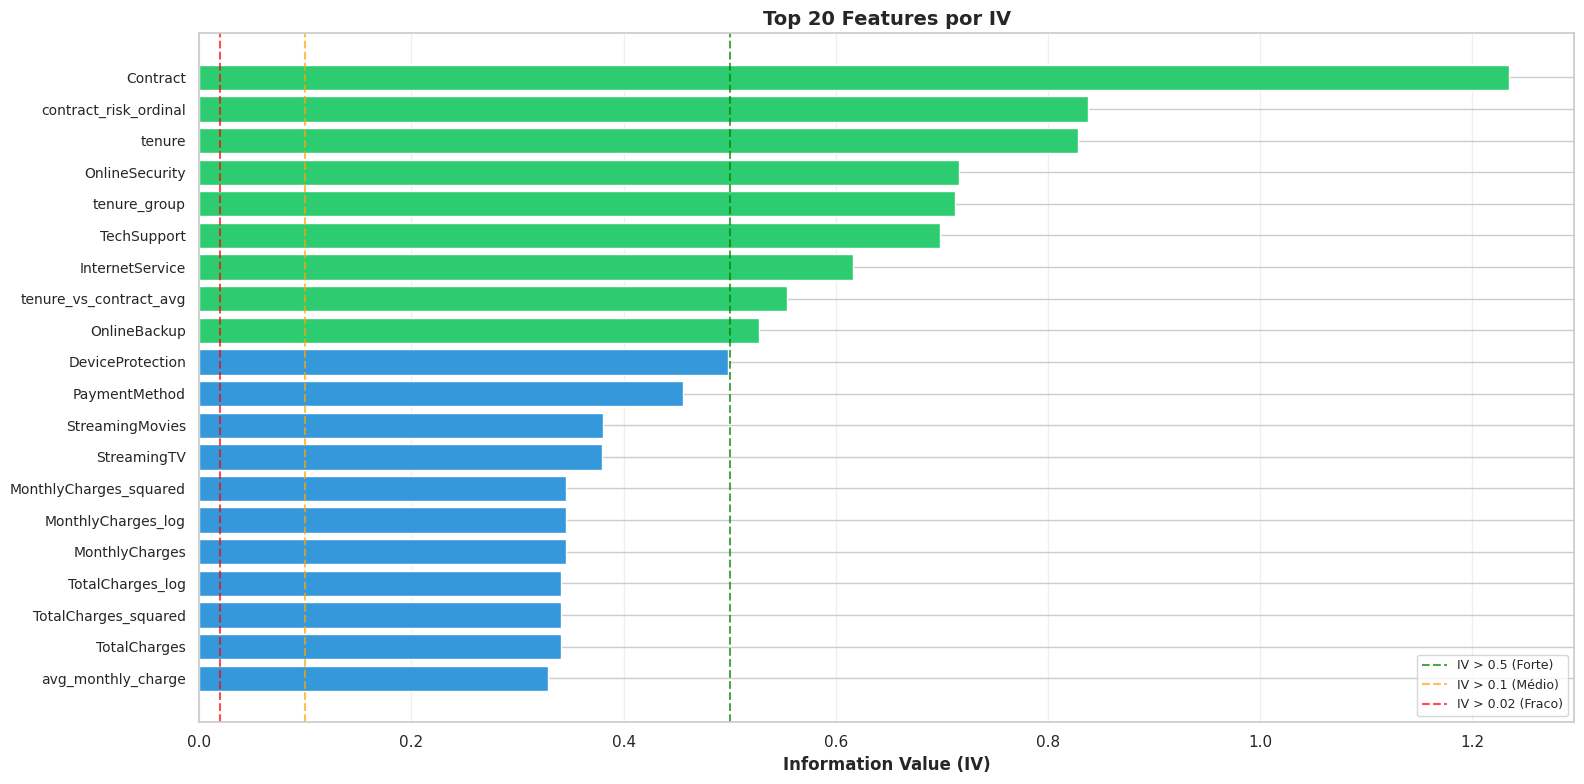

In [18]:
# Visualização do IV
try:
 plot_iv_ranking_and_summary(iv_df)
except Exception as e:
 print(f"Visualização indisponível: {e}")

## 5. Pipeline de Preprocessamento

Construímos um pipeline de transformação usando `sklearn.pipeline` que encapsula todas as etapas de preprocessamento:
- **Variáveis numéricas:** `StandardScaler` para normalização (média 0, desvio 1)
- **Variáveis categóricas:** `OneHotEncoder` para converter categorias em variáveis binárias

O pipeline é ajustado (`fit`) nos dados completos neste notebook para fins exploratórios. Na modelagem (notebook 03), o pipeline será ajustado **apenas nos dados de treino** para evitar data leakage.

In [19]:
# Construir e ajustar pipeline
preprocessor = build_preprocessor(
 numeric_features=NUMERIC_COLS,
 categorical_features=CATEGORICAL_COLS
)

X = df.drop(columns=[TARGET])
y = df[TARGET]

preprocessor.fit(X, y)
X_processed = preprocessor.transform(X)

print(f" Shape original: {X.shape}")
print(f" Shape processado: {X_processed.shape}")

2026-03-05 11:11:39 - src.preprocessing - INFO - Construindo preprocessador
2026-03-05 11:11:39 - src.preprocessing - INFO - Scaler selecionado: robust
2026-03-05 11:11:39 - src.preprocessing - INFO - Pipeline numérico configurado: 20 features
2026-03-05 11:11:39 - src.preprocessing - INFO - Pipeline categórico configurado: 17 features
2026-03-05 11:11:39 - src.preprocessing - INFO - Preprocessador construído com sucesso


 Shape original: (7043, 38)
 Shape processado: (7043, 70)


## 6. Validação e Export

Antes de salvar os artefatos, realizamos duas verificações críticas:
1. **Data leakage** — Nenhuma feature deve ter correlação quase perfeita (|r| > 0.95) com o target, o que indicaria vazamento de informação do futuro
2. **Integridade** — Ausência de valores nulos nas features selecionadas, shapes consistentes

### 6.1 Validação de Data Leakage

Verificamos se alguma feature numérica tem correlação superior a 0.95 com o target — um sinal de possível leakage. Correlações moderadas (0.3–0.5) são esperadas e desejáveis; correlações extremas indicam que a feature contém informação que não estaria disponível no momento da predição.

In [20]:
from sklearn.preprocessing import LabelEncoder

# Correlação com target
y_enc = LabelEncoder().fit_transform(y)
corr_with_target = []

for col in NUMERIC_COLS:
 if df[col].notna().sum() > 1 and df[col].nunique() > 1:
    corr = np.corrcoef(df[col].fillna(0), y_enc)[0, 1]
    corr_with_target.append({'Feature': col, 'Correlation': corr})

corr_df = pd.DataFrame(corr_with_target).sort_values('Correlation', key=abs, ascending=False)

# Verificar leakage (|corr| > 0.95)
high_corr = corr_df[corr_df['Correlation'].abs() > 0.95]
if len(high_corr) > 0:
    print("[!] ALERTA: Possível leakage detectado!")
    print(high_corr)
else:
    print("[OK] Sem evidência de data leakage (nenhuma correlação > 0.95)")

print("\nTop 10 correlações com target:")
corr_df.head(10)

[OK] Sem evidência de data leakage (nenhuma correlação > 0.95)

Top 10 correlações com target:


,Feature,Correlation
8,is_monthly_contract,0.405103
9,long_term_contract,-0.405103
10,contract_risk_ordinal,-0.396713
12,price_sensitive_contract,0.380429
1,tenure,-0.352229
11,early_churn_risk,0.350696
16,TotalCharges_log,-0.233966
14,MonthlyCharges_log,0.210109
18,avg_monthly_charge_log,0.206663
3,TotalCharges,-0.198324


### 6.2 Salvar Artefatos

Persistimos os artefatos gerados para uso nos notebooks subsequentes e para documentação do pipeline:
- **Dataset com features** — CSV com todas as colunas originais + features criadas
- **Pipeline de preprocessamento** — Objeto serializado para reutilização
- **Lista de features selecionadas** — JSON para referência e versionamento
- **Schema de features** — JSON com tipo e IV de cada feature
- **Ranking de IV** — CSV para análise e relatórios

In [21]:
# Criar diretórios se não existirem
DATA_DIR_PROCESSED.mkdir(parents=True, exist_ok=True)
reports_dir = PROJ_ROOT / 'reports'
reports_dir.mkdir(parents=True, exist_ok=True)

# 1. Dataset processado
df.to_csv(DATA_DIR_PROCESSED / 'telco_features.csv', index=False)

# 2. Pipeline de preprocessamento
joblib.dump(preprocessor, DATA_DIR_PROCESSED / 'preprocessor.joblib')

# 3. Lista de features selecionadas
selected_features = NUMERIC_COLS + CATEGORICAL_COLS
with open(DATA_DIR_PROCESSED / 'selected_features.json', 'w') as f:
 json.dump(selected_features, f, indent=2)

# 4. Schema de features
feature_schema = [
 {'feature': col, 'type': str(df[col].dtype), 'iv': iv_df[iv_df['Feature']==col]['IV'].values[0] if col in iv_df['Feature'].values else None}
 for col in selected_features
]
with open(DATA_DIR_PROCESSED / 'feature_schema.json', 'w') as f:
 json.dump(feature_schema, f, indent=2)

# 5. Ranking de IV
iv_df.to_csv(reports_dir / 'iv_rank.csv', index=False)

print("Artefatos salvos em:", DATA_DIR_PROCESSED)
print(" - telco_features.csv")
print(" - preprocessor.joblib")
print(" - selected_features.json")
print(" - feature_schema.json")
print(f"Ranking IV salvo em: {reports_dir / 'iv_rank.csv'}")

Artefatos salvos em: /home/gabriela/Projetos/telco_churn_clients/src/data/processed
 - telco_features.csv
 - preprocessor.joblib
 - selected_features.json
 - feature_schema.json
Ranking IV salvo em: /home/gabriela/Projetos/telco_churn_clients/reports/iv_rank.csv


### 6.3 Verificação Final

Checagem de integridade dos artefatos: dimensões do dataset, ausência de nulos nas features selecionadas e contagem de features por faixa de poder preditivo (IV).

In [22]:
# Checagem de integridade
print(" Verificação Final:\n")
print(f" Dataset shape: {df.shape}")
print(f" Nulos totais: {df[selected_features].isnull().sum().sum()}")
print(f" Features numéricas: {len(NUMERIC_COLS)}")
print(f" Features categóricas: {len(CATEGORICAL_COLS)}")
print(f" Features com IV > 0.3 (forte): {len(iv_df[iv_df['IV'] > 0.3])}")
print(f" Features com IV > 0.1 (médio+): {len(iv_df[iv_df['IV'] > 0.1])}")

 Verificação Final:

 Dataset shape: (7043, 39)
 Nulos totais: 0
 Features numéricas: 20
 Features categóricas: 17
 Features com IV > 0.3 (forte): 23
 Features com IV > 0.1 (médio+): 26


In [23]:
# Preview do dataset final
df[selected_features[:10] + [TARGET]].head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,new_customer_flag,avg_monthly_charge,charges_mismatch_flag,is_high_MonthlyCharges,is_monthly_contract,long_term_contract,Churn
0,0,1,29.85,29.85,0,29.850000,0,0,1,0,0
1,0,34,56.95,1889.50,0,55.573529,0,0,0,1,0
2,0,2,53.85,108.15,0,54.075000,0,0,1,0,1
3,0,45,42.30,1840.75,0,40.905556,0,0,0,1,0
4,0,2,70.70,151.65,0,75.825000,0,1,1,0,1


---

## Resumo

### Features Criadas

| Categoria | Features | Descrição | Insight da EDA |
|-----------|----------|----------|----------------|
| **Tenure** | `new_customer_flag`, `tenure_group` | Segmentação temporal do cliente | Churn bimodal: altíssimo em novos, baixo em antigos |
| **Cobrança** | `avg_monthly_charge`, `charges_mismatch_flag`, `is_high_MonthlyCharges`, `MonthlyCharges_binned` | Padrões de gasto e anomalias | Clientes que pagam mais com menos serviços cancelam mais |
| **Contrato** | `is_monthly_contract`, `long_term_contract`, `contract_risk_ordinal` | Tipo de vínculo e risco associado | Contrato mensal = 43% churn vs 3% em contratos longos |
| **Interações** | `early_churn_risk`, `price_sensitive_contract`, `tenure_vs_contract_avg` | Combinações comportamentais de risco | Perfis compostos capturam mais risco que variáveis isoladas |
| **Transformações** | `*_log`, `*_squared` | Não-linearidades para modelos lineares | Reduz skewness e captura efeitos quadráticos |

### Validações Realizadas

- Sem data leakage — nenhuma feature com correlação > 0.95 com o target
- Sem valores nulos nas features selecionadas
- Pipeline de preprocessamento salvo e reproduzível

### Próximos Passos

1. **03_modeling.ipynb** — Treinamento, otimização (Optuna) e avaliação de modelos com as features criadas
2. **04_shap_interpretability.ipynb** — Interpretabilidade: entender quais features o modelo realmente usa e como

---

## Nota sobre Arquitetura: Artefatos Exploratórios vs Produção

### O que foi salvo aqui vs o que é usado na modelagem

Os artefatos salvos neste notebook (`telco_features.csv`, `preprocessor.joblib`, `selected_features.json`, `feature_schema.json`) servem principalmente para **documentação, análise exploratória e rastreabilidade**. Eles **não** são carregados diretamente pelo notebook de modelagem.

**Por que essa separação?**

O notebook de modelagem (`03_modeling.ipynb`) segue uma arquitetura mais robusta:

1. **Carrega dados do RAW** — `pd.read_csv(DATA_DIR_RAW / FILENAME)` (fonte única de verdade)
2. **Aplica Feature Engineering via código** — Usa `FeatureEngineer` de `src/feature_engineering.py` (não depende de CSVs intermediários)
3. **Cria pipeline integrado** — O preprocessamento é acoplado ao pipeline de treinamento, garantindo que o `fit` ocorra apenas nos dados de treino

### Benefícios desta arquitetura

- **Reprodutibilidade** — Todo o fluxo (raw → features → preprocessing → modelo) é executável em um único pipeline
- **Zero data leakage** — O pipeline garante que transformações sejam ajustadas apenas no treino
- **Deploy simplificado** — O artefato de produção (`models/*.joblib`) contém tudo necessário para inferência
- **Versionamento** — Alterações nas features são rastreadas no código-fonte (`src/feature_engineering.py`), não em CSVs